<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-3-Holonomic-Mechanics/Untitled146.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding Geodesics on a Cone**

**Hard embeding method**
Consider the parametrization of the right circular upper cone with respect to latent coordinates $\xi= (r, \theta)$
$$
\Phi(r,\varphi)
=
\bigl(r\cos\varphi,\; r\sin\varphi,\; r\bigr),
\qquad
r>0,\ \varphi\in[0,2\pi).
$$
In this setting, the initial point $(x_0,y_0,z_0)=(1,0,1)$ on the cone corresponds
to the latent coordinates
$$
\xi_0=(r_0,\varphi_0)=(1,0).
$$
The coordinate tangent vectors are
$\{\partial_r\Phi,\partial_\varphi\Phi\}$.


We consider three distinct initial velocities at the point $\xi_0$:
$$
v_{\mathrm{gen}}
=(1,0,1)
=\partial_r\Phi\big|_{\xi_0},
$$
$$
v_{\mathrm{circ}}
=(0,1,0)
=\partial_\varphi\Phi\big|_{\xi_0},
$$
$$
v_{\mathrm{slant}}
=(1,2,1)
=\partial_r\Phi\big|_{\xi_0}
+2\,\partial_\varphi\Phi\big|_{\xi_0}.
$$
We shall simulate geodesics in each of thee initial conditions.

How to use: set CASE = "gen" or "circ" or "slant" near the top and run the script. It will train the latent hard-embedded PINN, then plot (1) the loss curve and (2) the resulting geodesic on the cone in $R^3$.

We provide below all ofthese three cases:

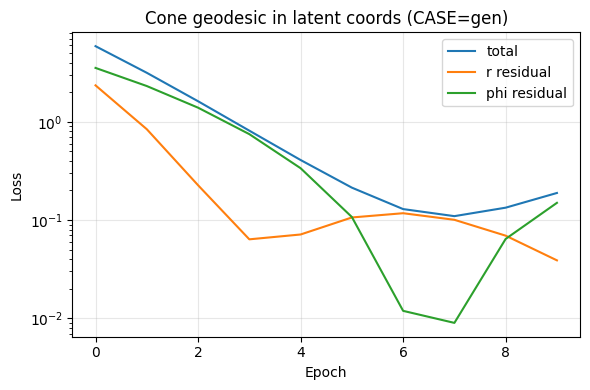

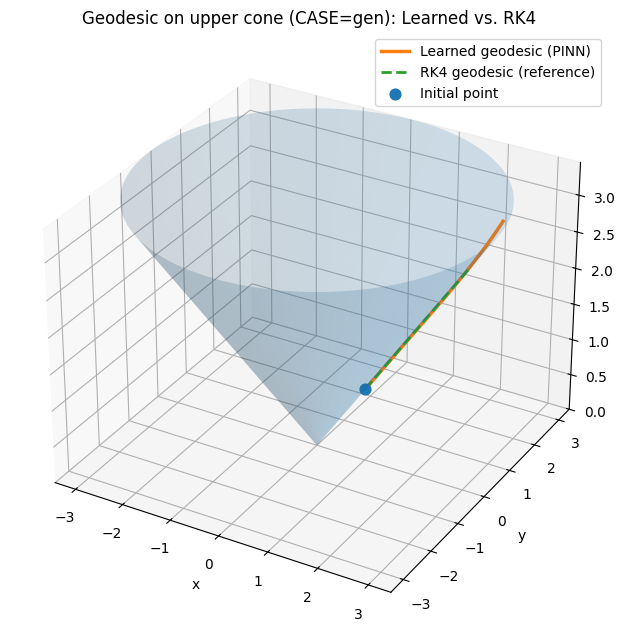

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
s
# ============================================================
# Geodesics on the upper cone via hard embedding in latent coords
#   Phi(r,phi) = (r cos phi, r sin phi, r)
#   Geodesic system:
#       r¨ - (r/2) * phi˙^2 = 0   <=>  r¨ = (r/2) * phi˙^2
#       phi¨ + (2/r) * r˙ * phi˙ = 0
#   Hard embedding:
#       xi_theta(t) = xi0 + t v0 + t^2 nn_theta(t)
#   PLUS: RK4 "exact" reference solution of the ODE system
# ============================================================

tf.random.set_seed(0)
np.random.seed(0)

# -----------------------
# User-chosen settings
# -----------------------
T_final = 2.0
N = 300              # collocation points
EPOCHS = 10
lr = 1e-3

# Choose initial velocity in latent coordinates: [a,b] at xi0
# v_gen  = [1,0]
# v_circ = [0,1]
# v_slant= [1,2]
CASE = "gen"  # one of: "gen", "circ", "slant"

# -----------------------
# Initial data in latent coordinates
# -----------------------
r0 = 1.0
phi0 = 0.0
xi0 = tf.constant([[r0, phi0]], dtype=tf.float32)

if CASE == "gen":
    v0 = tf.constant([[1.0, 0.0]], dtype=tf.float32)   # (r_dot0, phi_dot0)
elif CASE == "circ":
    v0 = tf.constant([[0.0, 1.0]], dtype=tf.float32)
elif CASE == "slant":
    v0 = tf.constant([[1.0, 2.0]], dtype=tf.float32)
else:
    raise ValueError("CASE must be one of: 'gen', 'circ', 'slant'")

# -----------------------
# Collocation points
# -----------------------
t_colloc = np.linspace(0.0, T_final, N, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# -----------------------
# Network: nn_theta(t) -> R^2 (correction in latent space)
# -----------------------
def build_latent_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="swish"),
        layers.Dense(64, activation="swish"),
        layers.Dense(2)  # outputs: (delta_r, delta_phi)
    ])

nn = build_latent_net()
opt = keras.optimizers.Adam(learning_rate=lr)

# -----------------------
# Hard-embedded latent trajectory
# xi_theta(t) = xi0 + t v0 + t^2 nn(t)
# -----------------------
def xi_theta(t):
    return xi0 + t * v0 + (t**2) * nn(t)  # (batch, 2)

# -----------------------
# Embedding Phi: (r,phi) -> (x,y,z)
# -----------------------
def Phi_tf(r, phi):
    x = r * tf.cos(phi)
    y = r * tf.sin(phi)
    z = r
    return tf.stack([x, y, z], axis=1)  # (batch, 3)

def Phi_np(r, phi):
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    z = r
    return np.stack([x, y, z], axis=1)  # (batch, 3)

# ============================================================
# Training: minimize residual of geodesic equations
# ============================================================
loss_hist = []
loss_r_hist = []
loss_phi_hist = []

eps = 1e-6  # avoid division by zero

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(N)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t_batch)
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch(t_batch)

                xi = xi_theta(t_batch)          # (batch, 2)
                r = xi[:, 0:1]                  # (batch, 1)
                phi = xi[:, 1:2]                # (batch, 1)

            # First derivatives
            dxi_dt = tf.squeeze(tape1.batch_jacobian(xi, t_batch), axis=-1)  # (batch, 2)
            dr_dt = dxi_dt[:, 0:1]
            dphi_dt = dxi_dt[:, 1:2]

            # Second derivatives
            d2xi_dt2 = tf.squeeze(tape2.batch_jacobian(dxi_dt, t_batch), axis=-1)  # (batch, 2)
            d2r_dt2 = d2xi_dt2[:, 0:1]
            d2phi_dt2 = d2xi_dt2[:, 1:2]

            # Residuals of geodesic equations
            # r¨ - (r/2) * phi˙^2 = 0
            res_r = d2r_dt2 - 0.5 * r * (dphi_dt**2)

            # phi¨ + (2/r) * r˙ * phi˙ = 0
            res_phi = d2phi_dt2 + (2.0 / (r + eps)) * dr_dt * dphi_dt

            loss_r = tf.reduce_mean(res_r**2)
            loss_phi = tf.reduce_mean(res_phi**2)
            loss = loss_r + loss_phi

        grads = tape2.gradient(loss, nn.trainable_variables)
        opt.apply_gradients(zip(grads, nn.trainable_variables))
        del tape1
        del tape2

    loss_hist.append(float(loss.numpy()))
    loss_r_hist.append(float(loss_r.numpy()))
    loss_phi_hist.append(float(loss_phi.numpy()))

    if (epoch + 1) % 25 == 0:
        print(f"[{CASE}] Epoch {epoch+1}/{EPOCHS} | "
              f"Loss: {loss_hist[-1]:.4e} | "
              f"r-res: {loss_r_hist[-1]:.2e} | "
              f"phi-res: {loss_phi_hist[-1]:.2e}")

# ============================================================
# 1) Plot loss across epochs
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label="total")
plt.plot(loss_r_hist, label="r residual")
plt.plot(loss_phi_hist, label="phi residual")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Cone geodesic in latent coords (CASE={CASE})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# RK4 reference solution of intrinsic geodesic equations
# State y = [r, phi, rdot, phidot]
#   rdot     = v_r
#   phidot   = v_phi
#   v_rdot   = (r/2) * v_phi^2
#   v_phidot = -(2/r) * v_r * v_phi
# ============================================================

def geodesic_rhs(t, y):
    r, phi, vr, vphi = y
    r_safe = max(r, 1e-8)
    dr = vr
    dphi = vphi
    dvr = 0.5 * r * (vphi**2)
    dvphi = -(2.0 / r_safe) * vr * vphi
    return np.array([dr, dphi, dvr, dvphi], dtype=np.float64)

def rk4_solve(y0, t_grid):
    y = np.zeros((len(t_grid), len(y0)), dtype=np.float64)
    y[0] = y0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i+1] - t_grid[i]
        k1 = geodesic_rhs(t, y[i])
        k2 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k1)
        k3 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k2)
        k4 = geodesic_rhs(t + h,     y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Time grid for plotting and RK4
t_plot = np.linspace(0.0, T_final, 600, dtype=np.float64)

# Initial conditions for RK4 (intrinsic)
v0_np = v0.numpy().reshape(-1)  # [rdot0, phidot0]
y0 = np.array([r0, phi0, float(v0_np[0]), float(v0_np[1])], dtype=np.float64)
Y_rk = rk4_solve(y0, t_plot)

r_rk = Y_rk[:, 0]
phi_rk = Y_rk[:, 1]

# Embedded RK4 curve in R^3
q_rk = Phi_np(r_rk, phi_rk)
xr, yr, zr = q_rk[:, 0], q_rk[:, 1], q_rk[:, 2]

# ============================================================
# Learned solution on the same time grid
# ============================================================
t_plot_tf = tf.constant(t_plot.astype(np.float32).reshape(-1, 1))
xi_learn = xi_theta(t_plot_tf)

r_learn = xi_learn[:, 0].numpy()
phi_learn = xi_learn[:, 1].numpy()

q_learn = Phi_tf(xi_learn[:, 0], xi_learn[:, 1]).numpy()
xg, yg, zg = q_learn[:, 0], q_learn[:, 1], q_learn[:, 2]

# ============================================================
# 2) Plot cone + learned geodesic + RK4 geodesic
# (cone scaled to cover BOTH curves)
# ============================================================

r_max = float(max(np.max(r_learn), np.max(r_rk)))
rho_max = 1.05 * r_max

rho = np.linspace(0.0, rho_max, 90)
th = np.linspace(0.0, 2*np.pi, 180)
RHO, TH = np.meshgrid(rho, th)
Xc = RHO * np.cos(TH)
Yc = RHO * np.sin(TH)
Zc = RHO

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")

# Cone surface
ax.plot_surface(Xc, Yc, Zc, alpha=0.18, linewidth=0)

# Curves
ax.plot(xg, yg, zg, linewidth=2.5, label="Learned geodesic (PINN)")
ax.plot(xr, yr, zr, linestyle="--", linewidth=2.0, label="RK4 geodesic (reference)")

# Initial point
ax.scatter([xg[0]], [yg[0]], [zg[0]], s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Geodesic on upper cone (CASE={CASE}): Learned vs. RK4")
ax.legend()

ax.set_xlim(-rho_max, rho_max)
ax.set_ylim(-rho_max, rho_max)
ax.set_zlim(0.0, rho_max)

plt.tight_layout()
plt.show()


[circ] Epoch 25/200 | Loss: 2.4948e-02 | r-res: 1.92e-02 | phi-res: 5.78e-03
[circ] Epoch 50/200 | Loss: 6.7994e-03 | r-res: 4.58e-03 | phi-res: 2.22e-03
[circ] Epoch 75/200 | Loss: 2.8678e-03 | r-res: 1.59e-03 | phi-res: 1.27e-03
[circ] Epoch 100/200 | Loss: 1.5850e-03 | r-res: 7.18e-04 | phi-res: 8.67e-04
[circ] Epoch 125/200 | Loss: 1.1850e-03 | r-res: 3.58e-04 | phi-res: 8.27e-04
[circ] Epoch 150/200 | Loss: 1.0836e-03 | r-res: 2.43e-04 | phi-res: 8.41e-04
[circ] Epoch 175/200 | Loss: 1.0521e-03 | r-res: 2.04e-04 | phi-res: 8.48e-04
[circ] Epoch 200/200 | Loss: 1.0319e-03 | r-res: 1.91e-04 | phi-res: 8.41e-04


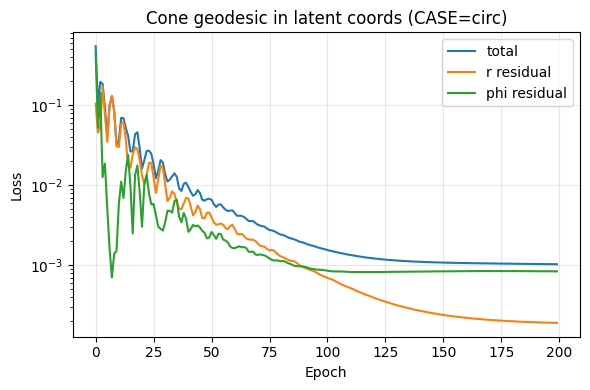

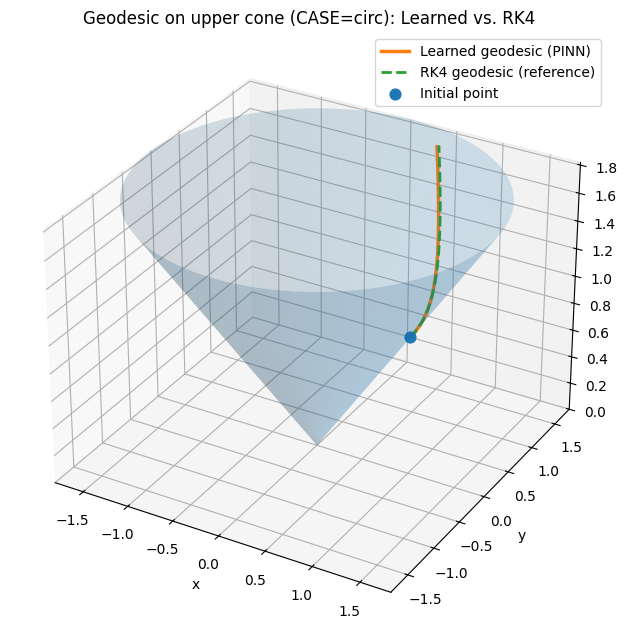

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Geodesics on the upper cone via hard embedding in latent coords
#   Phi(r,phi) = (r cos phi, r sin phi, r)
#   Geodesic system:
#       r¨ - (r/2) * phi˙^2 = 0   <=>  r¨ = (r/2) * phi˙^2
#       phi¨ + (2/r) * r˙ * phi˙ = 0
#   Hard embedding:
#       xi_theta(t) = xi0 + t v0 + t^2 nn_theta(t)
#   PLUS: RK4 "exact" reference solution of the ODE system
# ============================================================

tf.random.set_seed(0)
np.random.seed(0)

# -----------------------
# User-chosen settings
# -----------------------
T_final = 2.0
N = 300              # collocation points
EPOCHS = 200
lr = 1e-3

# Choose initial velocity in latent coordinates: [a,b] at xi0
# v_gen  = [1,0]
# v_circ = [0,1]
# v_slant= [1,2]
CASE = "circ"  # one of: "gen", "circ", "slant"

# -----------------------
# Initial data in latent coordinates
# -----------------------
r0 = 1.0
phi0 = 0.0
xi0 = tf.constant([[r0, phi0]], dtype=tf.float32)

if CASE == "gen":
    v0 = tf.constant([[1.0, 0.0]], dtype=tf.float32)   # (r_dot0, phi_dot0)
elif CASE == "circ":
    v0 = tf.constant([[0.0, 1.0]], dtype=tf.float32)
elif CASE == "slant":
    v0 = tf.constant([[1.0, 2.0]], dtype=tf.float32)
else:
    raise ValueError("CASE must be one of: 'gen', 'circ', 'slant'")

# -----------------------
# Collocation points
# -----------------------
t_colloc = np.linspace(0.0, T_final, N, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# -----------------------
# Network: nn_theta(t) -> R^2 (correction in latent space)
# -----------------------
def build_latent_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(2)  # outputs: (delta_r, delta_phi)
    ])

nn = build_latent_net()
opt = keras.optimizers.Adam(learning_rate=lr)

# -----------------------
# Hard-embedded latent trajectory
# xi_theta(t) = xi0 + t v0 + t^2 nn(t)
# -----------------------
def xi_theta(t):
    return xi0 + t * v0 + (t**2) * nn(t)  # (batch, 2)

# -----------------------
# Embedding Phi: (r,phi) -> (x,y,z)
# -----------------------
def Phi_tf(r, phi):
    x = r * tf.cos(phi)
    y = r * tf.sin(phi)
    z = r
    return tf.stack([x, y, z], axis=1)  # (batch, 3)

def Phi_np(r, phi):
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    z = r
    return np.stack([x, y, z], axis=1)  # (batch, 3)

# ============================================================
# Training: minimize residual of geodesic equations
# ============================================================
loss_hist = []
loss_r_hist = []
loss_phi_hist = []

eps = 1e-6  # avoid division by zero

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(N)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t_batch)
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch(t_batch)

                xi = xi_theta(t_batch)          # (batch, 2)
                r = xi[:, 0:1]                  # (batch, 1)
                phi = xi[:, 1:2]                # (batch, 1)

            # First derivatives
            dxi_dt = tf.squeeze(tape1.batch_jacobian(xi, t_batch), axis=-1)  # (batch, 2)
            dr_dt = dxi_dt[:, 0:1]
            dphi_dt = dxi_dt[:, 1:2]

            # Second derivatives
            d2xi_dt2 = tf.squeeze(tape2.batch_jacobian(dxi_dt, t_batch), axis=-1)  # (batch, 2)
            d2r_dt2 = d2xi_dt2[:, 0:1]
            d2phi_dt2 = d2xi_dt2[:, 1:2]

            # Residuals of geodesic equations
            # r¨ - (r/2) * phi˙^2 = 0
            res_r = d2r_dt2 - 0.5 * r * (dphi_dt**2)

            # phi¨ + (2/r) * r˙ * phi˙ = 0
            res_phi = d2phi_dt2 + (2.0 / (r + eps)) * dr_dt * dphi_dt

            loss_r = tf.reduce_mean(res_r**2)
            loss_phi = tf.reduce_mean(res_phi**2)
            loss = loss_r + loss_phi

        grads = tape2.gradient(loss, nn.trainable_variables)
        opt.apply_gradients(zip(grads, nn.trainable_variables))
        del tape1
        del tape2

    loss_hist.append(float(loss.numpy()))
    loss_r_hist.append(float(loss_r.numpy()))
    loss_phi_hist.append(float(loss_phi.numpy()))

    if (epoch + 1) % 25 == 0:
        print(f"[{CASE}] Epoch {epoch+1}/{EPOCHS} | "
              f"Loss: {loss_hist[-1]:.4e} | "
              f"r-res: {loss_r_hist[-1]:.2e} | "
              f"phi-res: {loss_phi_hist[-1]:.2e}")

# ============================================================
# 1) Plot loss across epochs
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label="total")
plt.plot(loss_r_hist, label="r residual")
plt.plot(loss_phi_hist, label="phi residual")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Cone geodesic in latent coords (CASE={CASE})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# RK4 reference solution of intrinsic geodesic equations
# State y = [r, phi, rdot, phidot]
#   rdot     = v_r
#   phidot   = v_phi
#   v_rdot   = (r/2) * v_phi^2
#   v_phidot = -(2/r) * v_r * v_phi
# ============================================================

def geodesic_rhs(t, y):
    r, phi, vr, vphi = y
    r_safe = max(r, 1e-8)
    dr = vr
    dphi = vphi
    dvr = 0.5 * r * (vphi**2)
    dvphi = -(2.0 / r_safe) * vr * vphi
    return np.array([dr, dphi, dvr, dvphi], dtype=np.float64)

def rk4_solve(y0, t_grid):
    y = np.zeros((len(t_grid), len(y0)), dtype=np.float64)
    y[0] = y0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i+1] - t_grid[i]
        k1 = geodesic_rhs(t, y[i])
        k2 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k1)
        k3 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k2)
        k4 = geodesic_rhs(t + h,     y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Time grid for plotting and RK4
t_plot = np.linspace(0.0, T_final, 600, dtype=np.float64)

# Initial conditions for RK4 (intrinsic)
v0_np = v0.numpy().reshape(-1)  # [rdot0, phidot0]
y0 = np.array([r0, phi0, float(v0_np[0]), float(v0_np[1])], dtype=np.float64)
Y_rk = rk4_solve(y0, t_plot)

r_rk = Y_rk[:, 0]
phi_rk = Y_rk[:, 1]

# Embedded RK4 curve in R^3
q_rk = Phi_np(r_rk, phi_rk)
xr, yr, zr = q_rk[:, 0], q_rk[:, 1], q_rk[:, 2]

# ============================================================
# Learned solution on the same time grid
# ============================================================
t_plot_tf = tf.constant(t_plot.astype(np.float32).reshape(-1, 1))
xi_learn = xi_theta(t_plot_tf)

r_learn = xi_learn[:, 0].numpy()
phi_learn = xi_learn[:, 1].numpy()

q_learn = Phi_tf(xi_learn[:, 0], xi_learn[:, 1]).numpy()
xg, yg, zg = q_learn[:, 0], q_learn[:, 1], q_learn[:, 2]

# ============================================================
# 2) Plot cone + learned geodesic + RK4 geodesic
# (cone scaled to cover BOTH curves)
# ============================================================

r_max = float(max(np.max(r_learn), np.max(r_rk)))
rho_max = 1.05 * r_max

rho = np.linspace(0.0, rho_max, 90)
th = np.linspace(0.0, 2*np.pi, 180)
RHO, TH = np.meshgrid(rho, th)
Xc = RHO * np.cos(TH)
Yc = RHO * np.sin(TH)
Zc = RHO

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")

# Cone surface
ax.plot_surface(Xc, Yc, Zc, alpha=0.18, linewidth=0)

# Curves
ax.plot(xg, yg, zg, linewidth=2.5, label="Learned geodesic (PINN)")
ax.plot(xr, yr, zr, linestyle="--", linewidth=2.0, label="RK4 geodesic (reference)")

# Initial point
ax.scatter([xg[0]], [yg[0]], [zg[0]], s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Geodesic on upper cone (CASE={CASE}): Learned vs. RK4")
ax.legend()

ax.set_xlim(-rho_max, rho_max)
ax.set_ylim(-rho_max, rho_max)
ax.set_zlim(0.0, rho_max)

plt.tight_layout()
plt.show()


[slant] Epoch 25/300 | Loss: 3.3597e+00 | r-res: 1.65e+00 | phi-res: 1.71e+00
[slant] Epoch 50/300 | Loss: 1.5287e+00 | r-res: 7.75e-01 | phi-res: 7.54e-01
[slant] Epoch 75/300 | Loss: 7.9258e-01 | r-res: 3.00e-01 | phi-res: 4.93e-01
[slant] Epoch 100/300 | Loss: 5.8755e-01 | r-res: 1.85e-01 | phi-res: 4.02e-01
[slant] Epoch 125/300 | Loss: 4.7661e-01 | r-res: 1.52e-01 | phi-res: 3.24e-01
[slant] Epoch 150/300 | Loss: 3.7163e-01 | r-res: 1.22e-01 | phi-res: 2.50e-01
[slant] Epoch 175/300 | Loss: 2.7663e-01 | r-res: 9.14e-02 | phi-res: 1.85e-01
[slant] Epoch 200/300 | Loss: 1.9576e-01 | r-res: 6.32e-02 | phi-res: 1.33e-01
[slant] Epoch 225/300 | Loss: 1.3476e-01 | r-res: 4.09e-02 | phi-res: 9.38e-02
[slant] Epoch 250/300 | Loss: 9.5921e-02 | r-res: 2.71e-02 | phi-res: 6.88e-02
[slant] Epoch 275/300 | Loss: 7.5181e-02 | r-res: 2.06e-02 | phi-res: 5.46e-02
[slant] Epoch 300/300 | Loss: 6.5265e-02 | r-res: 1.80e-02 | phi-res: 4.72e-02


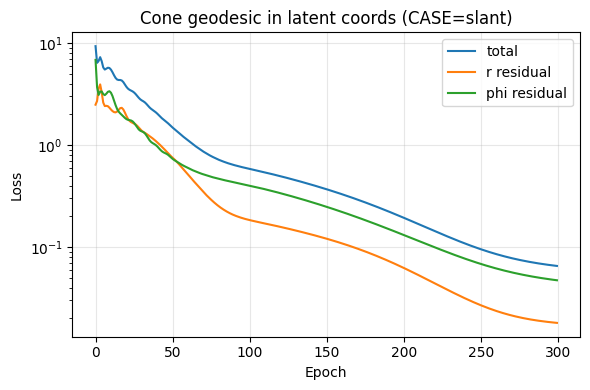

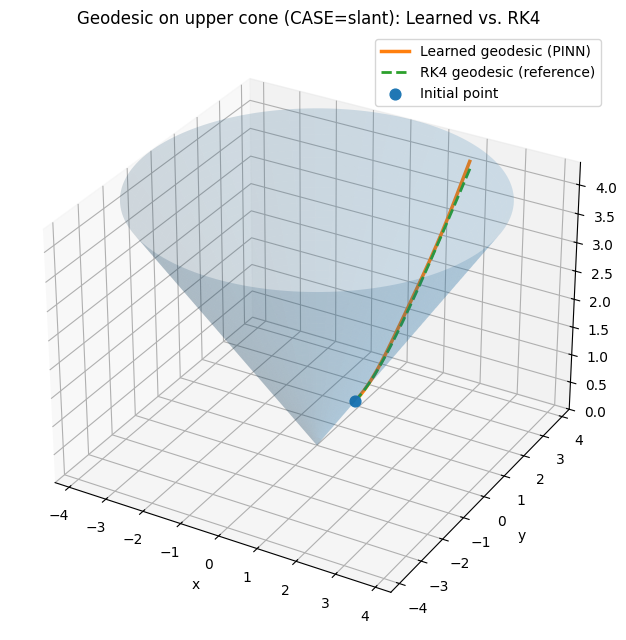

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Geodesics on the upper cone via hard embedding in latent coords
#   Phi(r,phi) = (r cos phi, r sin phi, r)
#   Geodesic system:
#       r¨ - (r/2) * phi˙^2 = 0   <=>  r¨ = (r/2) * phi˙^2
#       phi¨ + (2/r) * r˙ * phi˙ = 0
#   Hard embedding:
#       xi_theta(t) = xi0 + t v0 + t^2 nn_theta(t)
#   PLUS: RK4 "exact" reference solution of the ODE system
# ============================================================

tf.random.set_seed(0)
np.random.seed(0)

# -----------------------
# User-chosen settings
# -----------------------
T_final = 2.0
N = 300              # collocation points
EPOCHS = 300
lr = 1e-3

# Choose initial velocity in latent coordinates: [a,b] at xi0
# v_gen  = [1,0]
# v_circ = [0,1]
# v_slant= [1,2]
CASE = "slant"  # one of: "gen", "circ", "slant"

# -----------------------
# Initial data in latent coordinates
# -----------------------
r0 = 1.0
phi0 = 0.0
xi0 = tf.constant([[r0, phi0]], dtype=tf.float32)

if CASE == "gen":
    v0 = tf.constant([[1.0, 0.0]], dtype=tf.float32)   # (r_dot0, phi_dot0)
elif CASE == "circ":
    v0 = tf.constant([[0.0, 1.0]], dtype=tf.float32)
elif CASE == "slant":
    v0 = tf.constant([[1.0, 2.0]], dtype=tf.float32)
else:
    raise ValueError("CASE must be one of: 'gen', 'circ', 'slant'")

# -----------------------
# Collocation points
# -----------------------
t_colloc = np.linspace(0.0, T_final, N, dtype=np.float32).reshape(-1, 1)
t_colloc_tf = tf.constant(t_colloc)

# -----------------------
# Network: nn_theta(t) -> R^2 (correction in latent space)
# -----------------------
def build_latent_net():
    return keras.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(64, activation="tanh"),
        layers.Dense(64, activation="tanh"),
        layers.Dense(2)  # outputs: (delta_r, delta_phi)
    ])

nn = build_latent_net()
opt = keras.optimizers.Adam(learning_rate=lr)

# -----------------------
# Hard-embedded latent trajectory
# xi_theta(t) = xi0 + t v0 + t^2 nn(t)
# -----------------------
def xi_theta(t):
    return xi0 + t * v0 + (t**2) * nn(t)  # (batch, 2)

# -----------------------
# Embedding Phi: (r,phi) -> (x,y,z)
# -----------------------
def Phi_tf(r, phi):
    x = r * tf.cos(phi)
    y = r * tf.sin(phi)
    z = r
    return tf.stack([x, y, z], axis=1)  # (batch, 3)

def Phi_np(r, phi):
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    z = r
    return np.stack([x, y, z], axis=1)  # (batch, 3)

# ============================================================
# Training: minimize residual of geodesic equations
# ============================================================
loss_hist = []
loss_r_hist = []
loss_phi_hist = []

eps = 1e-6  # avoid division by zero

dataset = tf.data.Dataset.from_tensor_slices(t_colloc_tf).batch(N)

for epoch in range(EPOCHS):
    for t_batch in dataset:
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t_batch)
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch(t_batch)

                xi = xi_theta(t_batch)          # (batch, 2)
                r = xi[:, 0:1]                  # (batch, 1)
                phi = xi[:, 1:2]                # (batch, 1)

            # First derivatives
            dxi_dt = tf.squeeze(tape1.batch_jacobian(xi, t_batch), axis=-1)  # (batch, 2)
            dr_dt = dxi_dt[:, 0:1]
            dphi_dt = dxi_dt[:, 1:2]

            # Second derivatives
            d2xi_dt2 = tf.squeeze(tape2.batch_jacobian(dxi_dt, t_batch), axis=-1)  # (batch, 2)
            d2r_dt2 = d2xi_dt2[:, 0:1]
            d2phi_dt2 = d2xi_dt2[:, 1:2]

            # Residuals of geodesic equations
            # r¨ - (r/2) * phi˙^2 = 0
            res_r = d2r_dt2 - 0.5 * r * (dphi_dt**2)

            # phi¨ + (2/r) * r˙ * phi˙ = 0
            res_phi = d2phi_dt2 + (2.0 / (r + eps)) * dr_dt * dphi_dt

            loss_r = tf.reduce_mean(res_r**2)
            loss_phi = tf.reduce_mean(res_phi**2)
            loss = loss_r + loss_phi

        grads = tape2.gradient(loss, nn.trainable_variables)
        opt.apply_gradients(zip(grads, nn.trainable_variables))
        del tape1
        del tape2

    loss_hist.append(float(loss.numpy()))
    loss_r_hist.append(float(loss_r.numpy()))
    loss_phi_hist.append(float(loss_phi.numpy()))

    if (epoch + 1) % 25 == 0:
        print(f"[{CASE}] Epoch {epoch+1}/{EPOCHS} | "
              f"Loss: {loss_hist[-1]:.4e} | "
              f"r-res: {loss_r_hist[-1]:.2e} | "
              f"phi-res: {loss_phi_hist[-1]:.2e}")

# ============================================================
# 1) Plot loss across epochs
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(loss_hist, label="total")
plt.plot(loss_r_hist, label="r residual")
plt.plot(loss_phi_hist, label="phi residual")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Cone geodesic in latent coords (CASE={CASE})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# RK4 reference solution of intrinsic geodesic equations
# State y = [r, phi, rdot, phidot]
#   rdot     = v_r
#   phidot   = v_phi
#   v_rdot   = (r/2) * v_phi^2
#   v_phidot = -(2/r) * v_r * v_phi
# ============================================================

def geodesic_rhs(t, y):
    r, phi, vr, vphi = y
    r_safe = max(r, 1e-8)
    dr = vr
    dphi = vphi
    dvr = 0.5 * r * (vphi**2)
    dvphi = -(2.0 / r_safe) * vr * vphi
    return np.array([dr, dphi, dvr, dvphi], dtype=np.float64)

def rk4_solve(y0, t_grid):
    y = np.zeros((len(t_grid), len(y0)), dtype=np.float64)
    y[0] = y0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i+1] - t_grid[i]
        k1 = geodesic_rhs(t, y[i])
        k2 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k1)
        k3 = geodesic_rhs(t + 0.5*h, y[i] + 0.5*h*k2)
        k4 = geodesic_rhs(t + h,     y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return y

# Time grid for plotting and RK4
t_plot = np.linspace(0.0, T_final, 600, dtype=np.float64)

# Initial conditions for RK4 (intrinsic)
v0_np = v0.numpy().reshape(-1)  # [rdot0, phidot0]
y0 = np.array([r0, phi0, float(v0_np[0]), float(v0_np[1])], dtype=np.float64)
Y_rk = rk4_solve(y0, t_plot)

r_rk = Y_rk[:, 0]
phi_rk = Y_rk[:, 1]

# Embedded RK4 curve in R^3
q_rk = Phi_np(r_rk, phi_rk)
xr, yr, zr = q_rk[:, 0], q_rk[:, 1], q_rk[:, 2]

# ============================================================
# Learned solution on the same time grid
# ============================================================
t_plot_tf = tf.constant(t_plot.astype(np.float32).reshape(-1, 1))
xi_learn = xi_theta(t_plot_tf)

r_learn = xi_learn[:, 0].numpy()
phi_learn = xi_learn[:, 1].numpy()

q_learn = Phi_tf(xi_learn[:, 0], xi_learn[:, 1]).numpy()
xg, yg, zg = q_learn[:, 0], q_learn[:, 1], q_learn[:, 2]

# ============================================================
# 2) Plot cone + learned geodesic + RK4 geodesic
# (cone scaled to cover BOTH curves)
# ============================================================

r_max = float(max(np.max(r_learn), np.max(r_rk)))
rho_max = 1.05 * r_max

rho = np.linspace(0.0, rho_max, 90)
th = np.linspace(0.0, 2*np.pi, 180)
RHO, TH = np.meshgrid(rho, th)
Xc = RHO * np.cos(TH)
Yc = RHO * np.sin(TH)
Zc = RHO

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection="3d")

# Cone surface
ax.plot_surface(Xc, Yc, Zc, alpha=0.18, linewidth=0)

# Curves
ax.plot(xg, yg, zg, linewidth=2.5, label="Learned geodesic (PINN)")
ax.plot(xr, yr, zr, linestyle="--", linewidth=2.0, label="RK4 geodesic (reference)")

# Initial point
ax.scatter([xg[0]], [yg[0]], [zg[0]], s=60, label="Initial point")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Geodesic on upper cone (CASE={CASE}): Learned vs. RK4")
ax.legend()

ax.set_xlim(-rho_max, rho_max)
ax.set_ylim(-rho_max, rho_max)
ax.set_zlim(0.0, rho_max)

plt.tight_layout()
plt.show()
